In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np 

from keras import layers
from keras import models
from keras import backend as K
from keras import callbacks
from keras import optimizers

In [2]:
data = pd.read_csv('TrainFile.csv')

In [3]:
# convert pd to np array
variablesTrain = ["Muon_InnerTrack_eta", "Muon_InnerTrack_phi", "Muon_InnerTrack_charge", "Muon_InnerTrack_pt", "Muon_DT_s1_nhits","Muon_DT_s1_x_mean","Muon_DT_s1_y_mean","Muon_DT_s1_z_mean","Muon_DT_s1_x_std","Muon_DT_s1_y_std","Muon_DT_s1_z_std","Muon_DT_s2_nhits","Muon_DT_s2_x_mean","Muon_DT_s2_y_mean","Muon_DT_s2_z_mean","Muon_DT_s2_x_std","Muon_DT_s2_y_std","Muon_DT_s2_z_std","Muon_DT_s3_nhits","Muon_DT_s3_x_mean","Muon_DT_s3_y_mean","Muon_DT_s3_z_mean","Muon_DT_s3_x_std","Muon_DT_s3_y_std","Muon_DT_s3_z_std","Muon_DT_s4_nhits","Muon_DT_s4_x_mean","Muon_DT_s4_y_mean","Muon_DT_s4_z_mean","Muon_DT_s4_x_std","Muon_DT_s4_y_std","Muon_DT_s4_z_std","Muon_CSC_s1_nhits","Muon_CSC_s1_x_mean","Muon_CSC_s1_y_mean","Muon_CSC_s1_z_mean","Muon_CSC_s1_x_std","Muon_CSC_s1_y_std","Muon_CSC_s1_z_std","Muon_CSC_s2_nhits","Muon_CSC_s2_x_mean","Muon_CSC_s2_y_mean","Muon_CSC_s2_z_mean","Muon_CSC_s2_x_std","Muon_CSC_s2_y_std","Muon_CSC_s2_z_std","Muon_CSC_s3_nhits","Muon_CSC_s3_x_mean","Muon_CSC_s3_y_mean","Muon_CSC_s3_z_mean","Muon_CSC_s3_x_std","Muon_CSC_s3_y_std","Muon_CSC_s3_z_std","Muon_CSC_s4_nhits","Muon_CSC_s4_x_mean","Muon_CSC_s4_y_mean","Muon_CSC_s4_z_mean","Muon_CSC_s4_x_std","Muon_CSC_s4_y_std","Muon_CSC_s4_z_std"]
genpT = ["Muon_Genpt"]
train, test = train_test_split(data, test_size=0.2)


In [21]:
K.clear_session()

model = models.Sequential()

model.add(layers.Dense(128, activation='relu', input_dim=len(variablesTrain)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='linear'))

model.summary()

opt = optimizers.Adam(0.001)
model.compile(loss="mean_squared_error", optimizer=opt)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 128)               7808      
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_3 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_4 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 17        
Total params: 18,689
Trainable params: 18,689
Non-trainable params: 0
_________________________________________________________________


In [22]:
history = model.fit(train[variablesTrain],train[genpT],validation_split=0.1, epochs=1000, batch_size=1000, verbose=1, callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=50,verbose=1)])

Train on 90259 samples, validate on 10029 samples
Epoch 1/1000
90259/90259 [==============================] - 2s 22us/step - loss: 3496083.8145 - val_loss: 1706693.7808
Epoch 2/1000
90259/90259 [==============================] - 1s 7us/step - loss: 630477.9162 - val_loss: 122909.3848
Epoch 3/1000
90259/90259 [==============================] - 1s 7us/step - loss: 143511.4789 - val_loss: 114569.8949
Epoch 4/1000
90259/90259 [==============================] - 1s 7us/step - loss: 137265.6304 - val_loss: 98296.6013
Epoch 5/1000
90259/90259 [==============================] - 1s 7us/step - loss: 85252.7449 - val_loss: 79241.4031
Epoch 6/1000
90259/90259 [==============================] - 1s 7us/step - loss: 82654.4503 - val_loss: 89525.0656
Epoch 7/1000
90259/90259 [==============================] - 1s 7us/step - loss: 76381.5672 - val_loss: 75141.5357
Epoch 8/1000
90259/90259 [==============================] - 1s 7us/step - loss: 80399.2331 - val_loss: 121970.6604
Epoch 9/1000
90259/90259 [=

90259/90259 [==============================] - 1s 7us/step - loss: 47837.0945 - val_loss: 53685.2773
Epoch 72/1000
90259/90259 [==============================] - 1s 7us/step - loss: 47978.9554 - val_loss: 55965.1181
Epoch 73/1000
90259/90259 [==============================] - 1s 7us/step - loss: 47438.6662 - val_loss: 53101.5161
Epoch 74/1000
90259/90259 [==============================] - 1s 8us/step - loss: 46927.1474 - val_loss: 52922.4762
Epoch 75/1000
90259/90259 [==============================] - 1s 8us/step - loss: 46362.3768 - val_loss: 52850.7807
Epoch 76/1000
90259/90259 [==============================] - 1s 8us/step - loss: 46785.2202 - val_loss: 51723.3442
Epoch 77/1000
90259/90259 [==============================] - 1s 8us/step - loss: 47276.7165 - val_loss: 54639.3207
Epoch 78/1000
90259/90259 [==============================] - 1s 10us/step - loss: 46980.0815 - val_loss: 55447.6802
Epoch 79/1000
90259/90259 [==============================] - 1s 9us/step - loss: 45958.1735 -

Epoch 142/1000
90259/90259 [==============================] - 1s 7us/step - loss: 45181.5695 - val_loss: 51507.6170
Epoch 143/1000
90259/90259 [==============================] - 1s 7us/step - loss: 43094.2727 - val_loss: 53620.3313
Epoch 144/1000
90259/90259 [==============================] - 1s 8us/step - loss: 43087.7151 - val_loss: 49144.2581
Epoch 145/1000
90259/90259 [==============================] - 1s 7us/step - loss: 43650.7768 - val_loss: 54992.4792
Epoch 146/1000
90259/90259 [==============================] - 1s 8us/step - loss: 43061.1130 - val_loss: 50226.7525
Epoch 147/1000
90259/90259 [==============================] - 1s 7us/step - loss: 42071.9095 - val_loss: 49815.9778
Epoch 148/1000
90259/90259 [==============================] - 1s 7us/step - loss: 47405.5499 - val_loss: 58678.0062
Epoch 149/1000
90259/90259 [==============================] - 1s 7us/step - loss: 44097.9050 - val_loss: 51231.5122
Epoch 150/1000
90259/90259 [==============================] - 1s 7us/ste

90259/90259 [==============================] - 1s 10us/step - loss: 39584.0632 - val_loss: 48589.4495
Epoch 213/1000
90259/90259 [==============================] - 1s 9us/step - loss: 40284.2181 - val_loss: 50656.7265
Epoch 214/1000
90259/90259 [==============================] - 1s 8us/step - loss: 40098.7592 - val_loss: 49425.9233
Epoch 215/1000
90259/90259 [==============================] - 1s 9us/step - loss: 40050.1605 - val_loss: 49659.8725
Epoch 216/1000
90259/90259 [==============================] - 1s 10us/step - loss: 39627.1216 - val_loss: 47628.5189
Epoch 217/1000
90259/90259 [==============================] - 1s 8us/step - loss: 39291.5139 - val_loss: 46390.5301
Epoch 218/1000
90259/90259 [==============================] - 1s 9us/step - loss: 46834.0163 - val_loss: 65674.7298
Epoch 219/1000
90259/90259 [==============================] - 1s 9us/step - loss: 46044.4340 - val_loss: 52715.2517
Epoch 220/1000
90259/90259 [==============================] - 1s 9us/step - loss: 461

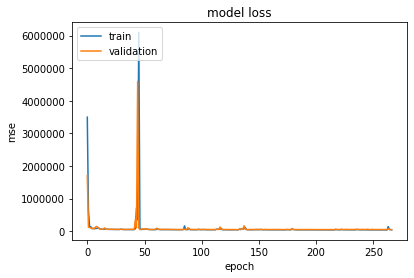

In [77]:
import matplotlib.pyplot as plt

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [68]:
results = model.evaluate(test[variablesTrain], test[genpT], batch_size=128)
print('test loss:', results)


25073/25073 [==============================] - 0s 10us/step
test loss: 47633.95417054077


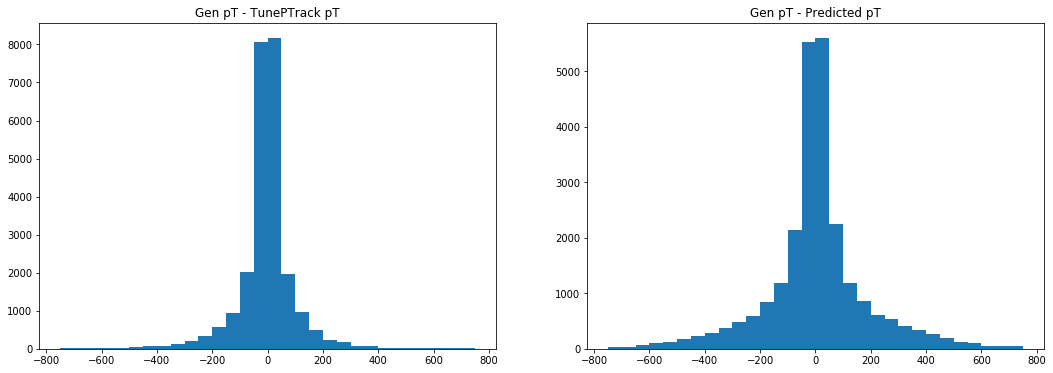

In [76]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


axes[0].hist(test.Muon_Genpt.values-test.Muon_TunePTrack_pt.values, bins = 30, range=(-750,750)) 
axes[0].set_title("Gen pT - TunePTrack pT") 
axes[1].hist(test.Muon_Genpt.values-model.predict(test[variablesTrain]).ravel(), bins = 30, range=(-750,750)) 
axes[1].set_title("Gen pT - Predicted pT") 
plt.show()